In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [2]:
df = pd.read_csv("../Data/Nassau Candy Distributor (1).csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 10194
Columns : 18


In [4]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [6]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [7]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [8]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True
)

print("Date conversion successful")

Date conversion successful


In [9]:
np.random.seed(42)

df["Lead Time"] = np.random.randint(
    2,
    15,
    size=len(df)
)

df["Lead Time"].head()

0     8
1     5
2    14
3    12
4     9
Name: Lead Time, dtype: int32

In [10]:
df["Profit Margin (%)"] = (
    df["Gross Profit"] / df["Sales"]
) * 100

df["Profit Margin (%)"].head()

0    64.923077
1    65.333333
2    71.346705
3    69.444444
4    65.333333
Name: Profit Margin (%), dtype: float64

In [11]:
np.random.seed(42)

df["Factory"] = np.random.choice(
    ["Factory A", "Factory B", "Factory C"],
    size=len(df)
)

df["Factory"].head()

0    Factory C
1    Factory A
2    Factory C
3    Factory C
4    Factory A
Name: Factory, dtype: str

In [12]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost', 'Lead Time', 'Profit Margin (%)', 'Factory']


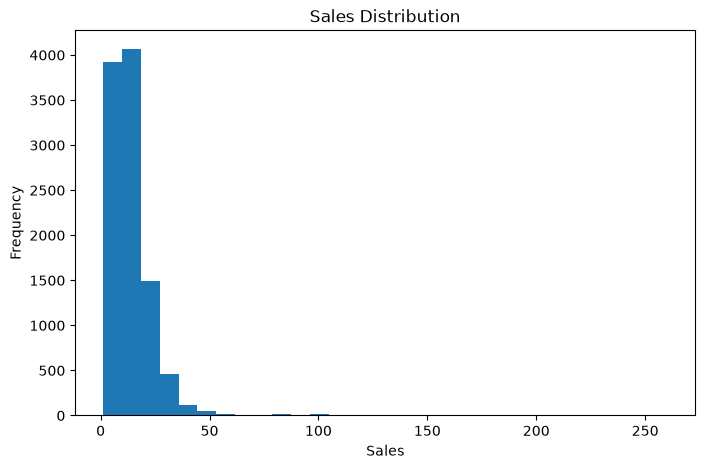

In [13]:
plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

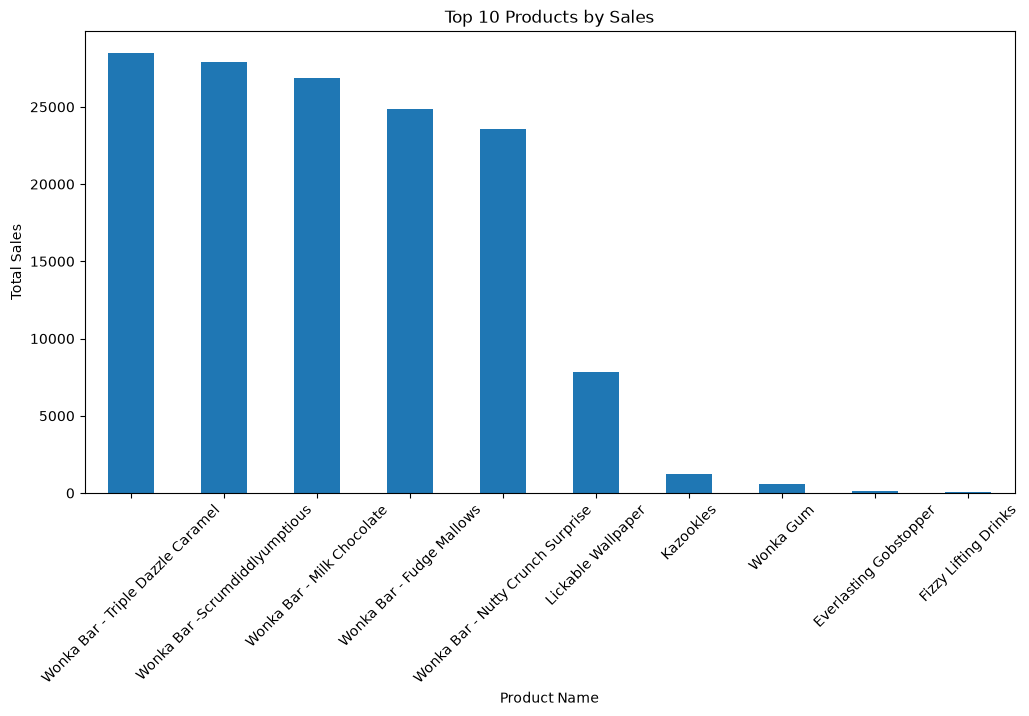

In [14]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
top_products.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

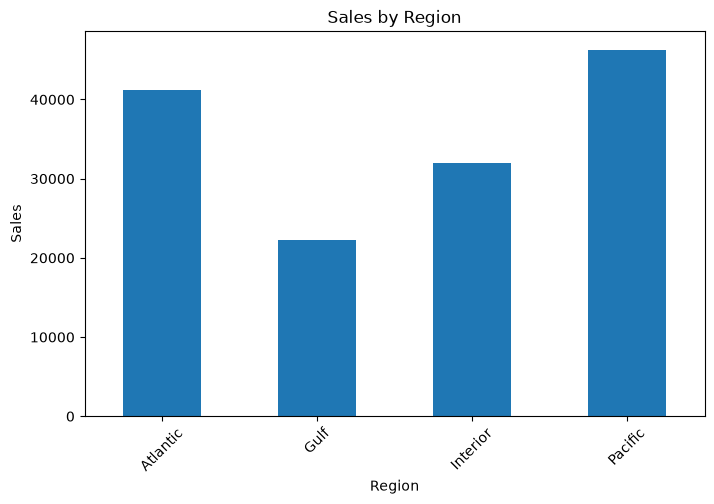

In [15]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

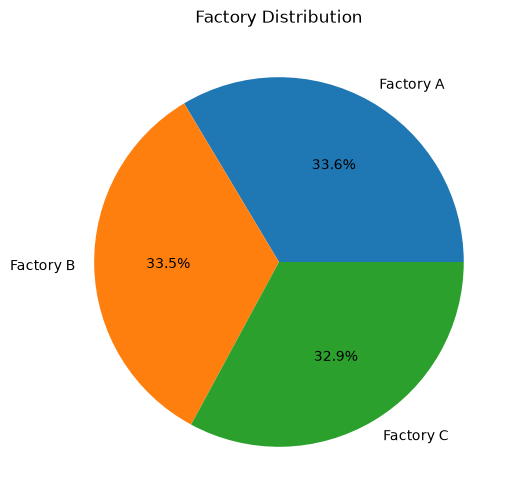

In [16]:
plt.figure(figsize=(6,6))

df["Factory"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Factory Distribution")
plt.show()

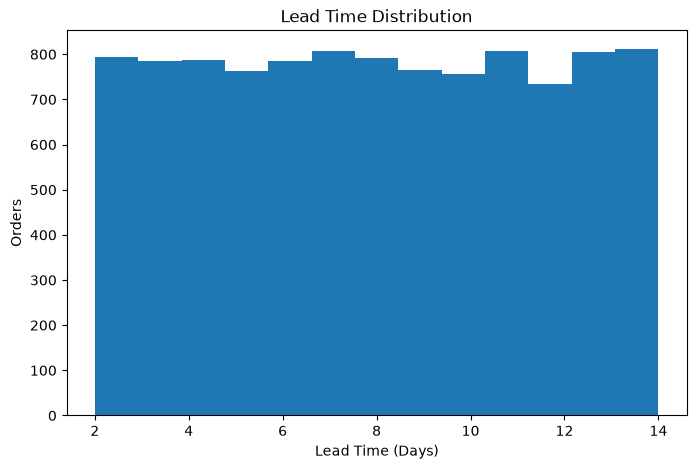

In [17]:
plt.figure(figsize=(8,5))

plt.hist(df["Lead Time"], bins=13)

plt.title("Lead Time Distribution")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Orders")
plt.show()

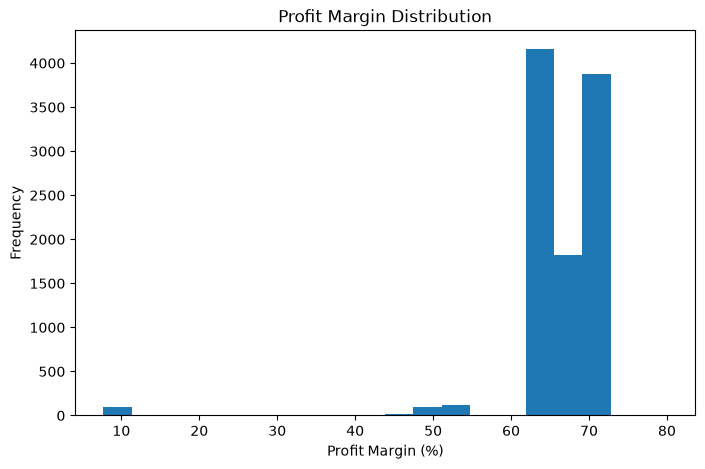

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df["Profit Margin (%)"], bins=20)

plt.title("Profit Margin Distribution")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.show()

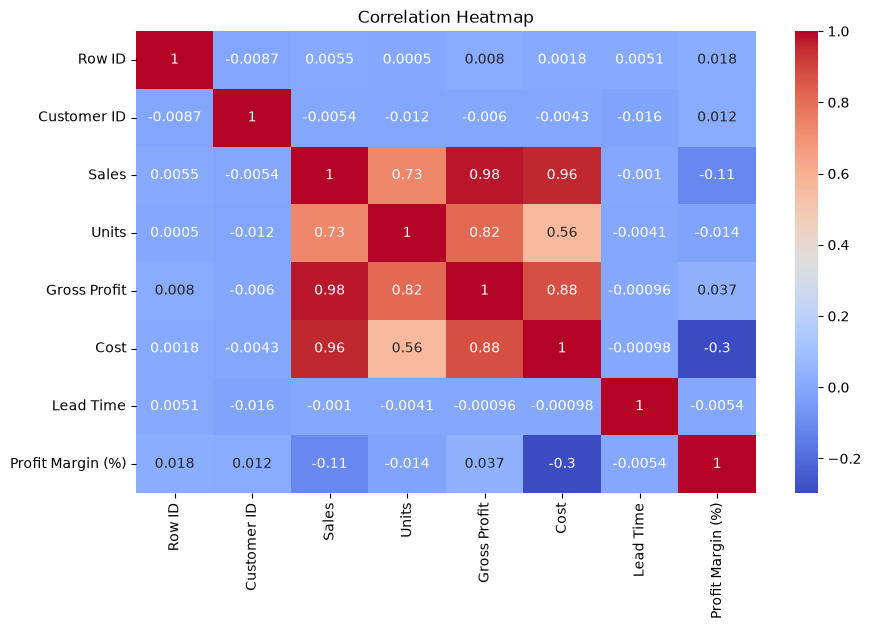

In [19]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [20]:
ship_encoder = LabelEncoder()
region_encoder = LabelEncoder()
factory_encoder = LabelEncoder()

df["Ship Mode"] = ship_encoder.fit_transform(df["Ship Mode"])

df["Region"] = region_encoder.fit_transform(df["Region"])

df["Factory"] = factory_encoder.fit_transform(df["Factory"])

print("Encoding Completed")

Encoding Completed


In [21]:
joblib.dump(ship_encoder, "../Models/ship_encoder.pkl")
joblib.dump(region_encoder, "../Models/region_encoder.pkl")
joblib.dump(factory_encoder, "../Models/factory_encoder.pkl")

print("Encoders Saved Successfully")

Encoders Saved Successfully


In [22]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Lead Time,Profit Margin (%),Factory
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,3,103800,United States,Houston,Texas,77095,...,2,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,8,64.923077,2
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,3,112326,United States,Naperville,Illinois,60540,...,2,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,5,65.333333,0
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,3,112326,United States,Naperville,Illinois,60540,...,2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,14,71.346705,2
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,3,112326,United States,Naperville,Illinois,60540,...,2,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,12,69.444444,2
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,3,141817,United States,Philadelphia,Pennsylvania,19143,...,0,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,9,65.333333,0


In [23]:
# Features
X = df[
    [
        "Sales",
        "Units",
        "Cost",
        "Gross Profit",
        "Ship Mode",
        "Region",
        "Factory"
    ]
]

# Target
y = df["Lead Time"]

print(X.head())
print(y.head())

   Sales  Units  Cost  Gross Profit  Ship Mode  Region  Factory
0   6.50      2  2.28          4.22          3       2        2
1   7.50      2  2.60          4.90          3       2        0
2  10.47      3  3.00          7.47          3       2        2
3  10.80      3  3.30          7.50          3       2        2
4  11.25      3  3.90          7.35          3       0        0
0     8
1     5
2    14
3    12
4     9
Name: Lead Time, dtype: int32


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8155, 7)
Testing Data: (2039, 7)


In [25]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_prediction = lr.predict(X_test)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [26]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_prediction = rf.predict(X_test)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [27]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

gb_prediction = gb.predict(X_test)

print("Gradient Boosting Model Trained Successfully")

Gradient Boosting Model Trained Successfully


In [28]:
lr_rmse = mean_squared_error(y_test, lr_prediction) ** 0.5

print("Linear Regression")

print("MAE :", mean_absolute_error(y_test, lr_prediction))
print("RMSE :", lr_rmse)
print("R2 :", r2_score(y_test, lr_prediction))

Linear Regression
MAE : 3.2682510160236293
RMSE : 3.777935764188795
R2 : -0.0019780731238658866


In [29]:
rf_rmse = mean_squared_error(y_test, rf_prediction) ** 0.5

print("Random Forest")

print("MAE :", mean_absolute_error(y_test, rf_prediction))
print("RMSE :", rf_rmse)
print("R2 :", r2_score(y_test, rf_prediction))

Random Forest
MAE : 3.4472396867651756
RMSE : 4.074977125630852
R2 : -0.16573390879895555


In [30]:
gb_rmse = mean_squared_error(y_test, gb_prediction) ** 0.5

print("Gradient Boosting")

print("MAE :", mean_absolute_error(y_test, gb_prediction))
print("RMSE :", gb_rmse)
print("R2 :", r2_score(y_test, gb_prediction))

Gradient Boosting
MAE : 3.275353871833329
RMSE : 3.7894822481701107
R2 : -0.008112112516811099


In [31]:
joblib.dump(
    rf,
    "../Models/random_forest_model.pkl"
)

print("Random Forest Model Saved Successfully")

Random Forest Model Saved Successfully


In [32]:
df.to_csv(
    "../Data/cleaned_nassau_candy.csv",
    index=False
)

print("Clean Dataset Saved Successfully")

Clean Dataset Saved Successfully


In [33]:
import os

print("Models Folder:")
print(os.listdir("../Models"))

print("\nData Folder:")
print(os.listdir("../Data"))

Models Folder:
['factory_encoder.pkl', 'random_forest_model.pkl', 'region_encoder.pkl', 'ship_encoder.pkl']

Data Folder:
['cleaned_nassau_candy.csv', 'Nassau Candy Distributor (1).csv']


In [34]:
from pathlib import Path
import sys

sys.path.append("../App")

from prediction import predict_lead_time

predict_lead_time(
    sales=100,
    units=5,
    cost=60,
    gross_profit=40,
    ship_mode=1,
    region=2,
    factory=0
)

ModuleNotFoundError: No module named 'prediction'

In [35]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost', 'Lead Time', 'Profit Margin (%)', 'Factory']
